In [ ]:
from numpy.lib import recfunctions as rfn
import numpy as np

def parse_to_recarray(path: str) -> np.recarray:
    def parse_header(x):
        if isinstance(x, bytes):
            x = x.decode()
        return int(x.replace("*", "").strip())

    data = np.genfromtxt(
        path,
        delimiter=",",
        dtype=[
            ("header", "i4"),
            ("pressure", "f8"),
            ("temp", "f8"),
            ("rh", "f8"),
            ("status", "i4")
        ],
        converters={0: parse_header},
        invalid_raise=False,
        ndmin=1,
    )

    rec = data.view(np.recarray)

    empty_time = np.zeros(rec.shape[0], dtype="f8")
    rec = rfn.append_fields(rec, "time", empty_time, usemask=False)     # Add a new field for time
    rec = rec.view(np.recarray)

    return rec

In [37]:
import numpy as np

def parse_to_recarray(path: str) -> np.recarray:
    rows = []

    with open(path, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue

            parts = line.split(",")
            
            try:
                header = int(parts[0].replace("*", "").strip())
                pressure = float(parts[1])
                temp = float(parts[2])
                rh = float(parts[3])
                status = int(parts[4])
            except ValueError:
                continue

            rows.append((0.0, header, pressure, temp, rh, status))

    arr = np.array(
        rows,
        dtype=[
            ("time", "f8"),
            ("header", "i4"),
            ("pressure", "f8"),
            ("temp", "f8"),
            ("rh", "f8"),
            ("status", "i4"),
        ]
    )

    return arr.view(np.recarray)

In [38]:
rec = parse_to_recarray("../2026_03_22/raw_data.txt")

print(rec.shape)
print(rec.pressure[:5])
print(rec.temp[:5])
print(rec.rh[:5])
print(rec.status[:5])

(1000,)
[39.924365 39.9243   39.924276 39.924326 39.924364]
[12.45 12.44 12.44 12.44 12.44]
[44.2 44.2 44.2 44.2 44.2]
[0 0 0 0 0]


In [ ]:
from met4a import convert_to_datetime


def coalesce_time_pressure(data_list, concatenate=False):
    """
    Coalesce multiple time and pressure arrays into single lists.

    Parameters
    ----------
    data_list : list of recarrays
        List of dictionaries, each containing 'start_time', 'times', and 'pressure' keys
    concatenate : bool, optional
        If True, concatenate the lists into single numpy arrays. If False, return as lists of arrays. Default is False.

    Returns
    -------
    coalesced_time : list or np.ndarray
        Coalesced time data, either as a list of arrays or a single concatenated array
    coalesced_pressure : list or np.ndarray
        Coalesced pressure data, either as a list of arrays or a single concatenated array
    """
    coalesced_time = []
    coalesced_pressure = []
    
    for data in data_list:
        time_axis = convert_to_datetime(data.time[0], data.time)
        coalesced_time.append(time_axis)
        coalesced_pressure.append(data.pressure)
    
    if concatenate:
        coalesced_time = np.concatenate(coalesced_time)
        coalesced_pressure = np.concatenate(coalesced_pressure)
    
    return coalesced_time, coalesced_pressure

In [27]:
from pathlib import Path

directory_path = "/workspaces/met4a_data/2026_03_22"
files = [str(p) for p in Path(directory_path).glob("*.txt")]
data_list = [parse_to_recarray(file) for file in files]

time, pressure = coalesce_time_pressure(data_list)

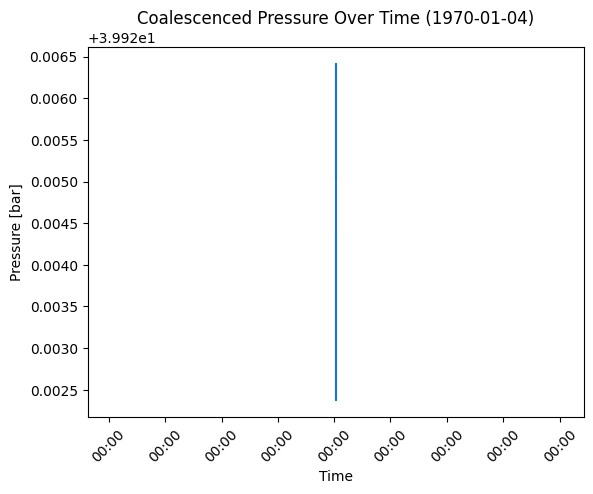

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()

for idx in range(len(time)):
    ax.plot(time[idx], pressure[idx])

date_str = time[0][0].strftime('%Y-%m-%d')
plt.title(f"Coalescenced Pressure Over Time ({date_str})")
plt.xlabel("Time")
plt.ylabel("Pressure [bar]")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45);

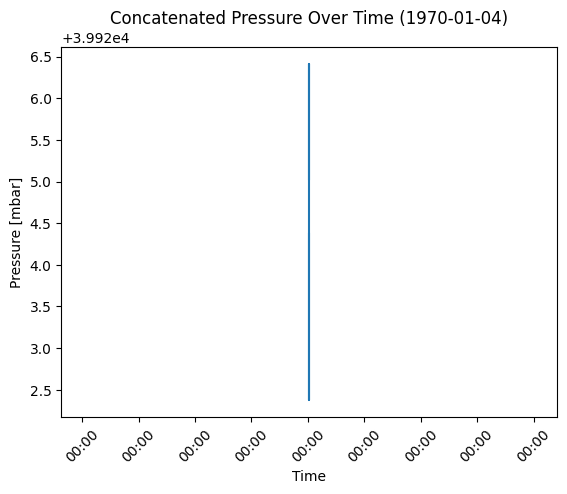

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data_list = [rec]

time, pressure = coalesce_time_pressure(data_list, concatenate=True)

pressure = pressure*1000 # Convert from bar to mbar

fig, ax = plt.subplots()

ax.plot(time, pressure)

date_str = time[0].astype('datetime64[ms]').item().strftime('%Y-%m-%d')
plt.title(f"Concatenated Pressure Over Time ({date_str})")
plt.xlabel("Time")
plt.ylabel("Pressure [mbar]")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45);